<a href="https://colab.research.google.com/github/pjm9814/Econometrics/blob/metrics_spring_2026/PS2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Dataset Generation
np.random.seed(123)
n = 500
x = np.random.normal(loc=0.0, scale = 1.0, size = n)
y = 1/ (1+ 0.5* np.exp(-2 * x)) + np.random.normal(loc=0.0, scale = 0.2, size = n)

#1. Data Visualization

###Draw a scatter plot of y_i vs x_i. Overlay the true logistic curve (without noise)

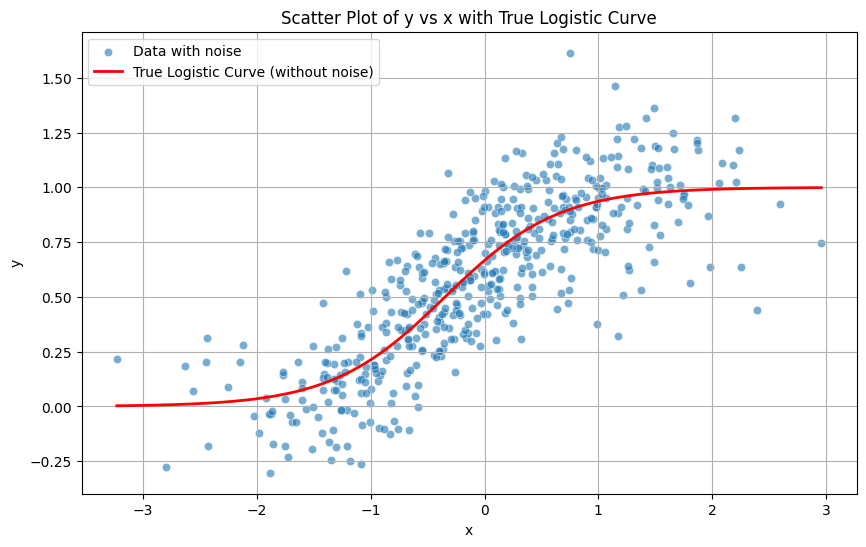

In [3]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=x, y=y, alpha=0.6, label='Data with noise')

# Calculate the true logistic curve without noise
x_true = np.linspace(min(x), max(x), 100)
y_true = 1 / (1 + 0.5 * np.exp(-2 * x_true))
sns.lineplot(x=x_true, y=y_true, color='red', linewidth=2, label='True Logistic Curve (without noise)')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter Plot of y vs x with True Logistic Curve')
plt.legend()
plt.grid(True)
plt.show()

#2. MLE Estimation

###Write the log-likelihood function analytically

Let the true relationship be $f(x; \theta_1, \theta_2, \theta_3) = \frac{\theta_1}{1 + \theta_2 e^{-\theta_3 x}}$.
The observed data $y_i$ is generated by $y_i = f(x_i; \theta_1, \theta_2, \theta_3) + \epsilon_i$, where $\epsilon_i$ are independent and identically distributed (i.i.d.) normal random variables with mean 0 and variance $\sigma^2$.
So, $y_i \sim N(f(x_i; \theta_1, \theta_2, \theta_3), \sigma^2)$.

The probability density function (PDF) for a single observation $y_i$ is:
$$ p(y_i | x_i, \theta_1, \theta_2, \theta_3, \sigma) = \frac{1}{\sqrt{2 \pi \sigma^2}} \exp\left(-\frac{(y_i - f(x_i; \theta_1, \theta_2, \theta_3))^2}{2 \sigma^2}\right) $$

For $n$ independent observations, the likelihood function $L$ is the product of the individual PDFs:
$$ L(\theta_1, \theta_2, \theta_3, \sigma^2 | x, y) = \prod_{i=1}^{n} p(y_i | x_i, \theta_1, \theta_2, \theta_3, \sigma^2) $$
$$ L(\theta_1, \theta_2, \theta_3, \sigma^2 | x, y) = \left(\frac{1}{2 \pi \sigma^2}\right)^{n/2} \exp\left(- \frac{1}{2 \sigma^2} \sum_{i=1}^{n} (y_i - f(x_i; \theta_1, \theta_2, \theta_3))^2\right) $$

The log-likelihood function $\log L$ is then:
$$ \log L(\theta_1, \theta_2, \theta_3, \sigma | x, y) = - \frac{n}{2} \log(2 \pi \sigma^2) - \frac{1}{2 \sigma^2} \sum_{i=1}^{n} (y_i - f(x_i; \theta_1, \theta_2, \theta_3))^2 $$

Substituting $f(x_i; \theta_1, \theta_2, \theta_3)$:
$$ \log L(\theta_1, \theta_2, \theta_3, \sigma | x, y) = - \frac{n}{2} \log(2 \pi \sigma^2) - \frac{1}{2 \sigma^2} \sum_{i=1}^{n} \left(y_i - \frac{\theta_1}{1 + \theta_2 e^{-\theta_3 x_i}}\right)^2 $$

###Code-up the log-likelihood function and report the MLE estimates (use optim function in R)

In [4]:
import numpy as np

def negative_log_likelihood(params, x, y):
    """Negative log-likelihood function to be minimized."""
    theta1, theta2, theta3, sigma = params

    # Ensure sigma remains positive to avoid math errors during optimization
    if sigma <= 0:
        return np.inf

    n = len(x)
    f_x = theta1 / (1 + theta2 * np.exp(-theta3 * x))

    # Analytical log-likelihood derived earlier:
    log_lik = - (n/2) * np.log(2 * np.pi * sigma**2) - (1 / (2 * sigma**2)) * np.sum((y - f_x)**2)

    return -log_lik

In [5]:
from scipy.optimize import minimize

# Initial guess: [theta1, theta2, theta3, sigma]
initial_guess = [1.0, 0.0, 0.0, 1.0]

# Minimize the negative log-likelihood (Equivalent to R's optim)
# Method 'L-BFGS-B' allows us to set bounds (e.g., sigma > 0)
results = minimize(negative_log_likelihood, initial_guess, args=(x, y),
                   bounds=[(None, None), (None, None), (None, None), (1e-6, None)])

# Extract and report estimates
theta1_mle, theta2_mle, theta3_mle, sigma_mle = results.x

print(f"MLE Results (using minimize):")
print(f"Estimated theta1: {theta1_mle:.4f}")
print(f"Estimated theta2: {theta2_mle:.4f}")
print(f"Estimated theta3: {theta3_mle:.4f}")
print(f"Estimated sigma:  {sigma_mle:.4f}")

MLE Results (using minimize):
Estimated theta1: 0.9745
Estimated theta2: 0.4518
Estimated theta3: 2.1621
Estimated sigma:  0.1996


###Write the score function

In [6]:
def score_function(params, x, y, sigma):
    """Calculates the score function (gradient of the log-likelihood)."""
    theta1, theta2, theta3 = params

    # Logistic model component
    exp_term = np.exp(-theta3 * x)
    denominator = 1 + theta2 * exp_term
    f_x = theta1 / denominator

    # Residuals
    residuals = y - f_x

    # Partial derivatives (Gradients)
    # dL/d_theta1
    d_theta1 = (1 / sigma**2) * np.sum(residuals * (1 / denominator))

    # dL/d_theta2
    d_theta2 = (1 / sigma**2) * np.sum(residuals * (-theta1 * exp_term / denominator**2))

    # dL/d_theta3
    d_theta3 = (1 / sigma**2) * np.sum(residuals * (theta1 * theta2 * x * exp_term / denominator**2))

    return np.array([d_theta1, d_theta2, d_theta3])

# Evaluate the score at the MLE estimates (excluding sigma)
mle_theta = [theta1_mle, theta2_mle, theta3_mle]
score_at_mle = score_function(mle_theta, x, y, sigma_mle)

print(f"Score function at MLE estimates: {score_at_mle}")

Score function at MLE estimates: [-2.61558737e-04  2.74048606e-04  6.97940922e-05]


###Calculate the standard errors for the estimated parameters

In [7]:
def individual_scores(params, x, y, sigma):
    """Calculates the gradient of the log-likelihood for each individual observation."""
    theta1, theta2, theta3 = params
    exp_term = np.exp(-theta3 * x)
    denominator = 1 + theta2 * exp_term
    f_x = theta1 / denominator
    residuals = y - f_x

    # Gradients for each observation i
    grad_theta1 = (residuals / sigma**2) * (1 / denominator)
    grad_theta2 = (residuals / sigma**2) * (-theta1 * exp_term / denominator**2)
    grad_theta3 = (residuals / sigma**2) * (theta1 * theta2 * x * exp_term / denominator**2)

    return np.column_stack([grad_theta1, grad_theta2, grad_theta3])

# Calculate individual scores at MLE
scores = individual_scores(mle_theta, x, y, sigma_mle)

# Outer Product of Gradients (OPG) estimator for the Information Matrix
# B = sum( score_i * score_i.T )
info_matrix_opg = scores.T @ scores

# Variance-Covariance matrix (inverse of Information Matrix)
vcv_opg = np.linalg.inv(info_matrix_opg)
standard_errors = np.sqrt(np.diag(vcv_opg))

print("Standard Errors for theta1, theta2, theta3 (using OPG):")
print(f"SE(theta1): {standard_errors[0]:.4f}")
print(f"SE(theta2): {standard_errors[1]:.4f}")
print(f"SE(theta3): {standard_errors[2]:.4f}")

Standard Errors for theta1, theta2, theta3 (using OPG):
SE(theta1): 0.0225
SE(theta2): 0.0557
SE(theta3): 0.1671


#3. GMM Estimation

We have the following moment conditions:

$E[(y_i - \frac{\theta_1}{1 + \theta_2 e^{-\theta_3 x_i}})] = 0$

$E[x_i(y_i - \frac{\theta_1}{1 + \theta_2 e^{-\theta_3 x_i}})] = 0$

$E[x_i^2(y_i - \frac{\theta_1}{1 + \theta_2 e^{-\theta_3 x_i}})] = 0$


Define GMM Moment Function


In [8]:
#define GMM moments function

def gmm_moments(params, x, y):
    """
    Calculates the sample average of the GMM moment conditions.

    Parameters:
    params : array-like, [theta1, theta2, theta3]
    x : ndarray, independent variable
    y : ndarray, dependent variable

    Returns:
    moments : ndarray, sample mean of the three moment conditions
    """
    theta1, theta2, theta3 = params

    # Logistic model prediction
    f_x = theta1 / (1 + theta2 * np.exp(-theta3 * x))

    # Residuals
    residuals = y - f_x

    # Moment conditions
    m1 = residuals
    m2 = x * residuals
    m3 = (x**2) * residuals

    # Return sample means
    return np.array([np.mean(m1), np.mean(m2), np.mean(m3)])

# Test the function with initial parameters
test_moments = gmm_moments([1.0, 0.5, 2.0], x, y)
print(f"Sample moments at theta=[1.0, 0.5, 2.0]: {test_moments}")

Sample moments at theta=[1.0, 0.5, 2.0]: [-0.00809686  0.00223367 -0.0159079 ]


In [9]:
#define GMM objective function

def gmm_objective(params, x, y, W):
    """Calculates the GMM objective function: g' * W * g."""
    moments = gmm_moments(params, x, y)
    return moments.T @ W @ moments

# 1. Define initial weighting matrix (Identity)
W1 = np.eye(3)

# 2. Initial guess
initial_guess_gmm = [1.0, 0.0, 0.0]

# 3. Minimize the GMM objective function with Identity matrix
res_step1 = minimize(gmm_objective, initial_guess_gmm, args=(x, y, W1), method='L-BFGS-B')

# 4. Store and print results
theta_step1 = res_step1.x
print(f"Step 1 GMM Estimates (Identity Matrix):")
print(f"theta1: {theta_step1[0]:.4f}")
print(f"theta2: {theta_step1[1]:.4f}")
print(f"theta3: {theta_step1[2]:.4f}")

Step 1 GMM Estimates (Identity Matrix):
theta1: 0.9723
theta2: 0.4459
theta3: 2.2266


**Reasoning**:
The first step of GMM using the identity matrix is completed. Now I will proceed to Step 2: GMM with an Efficient Weighting Matrix, as specified in the main task. This involves calculating the covariance matrix of the moments at the Step 1 estimates, inverting it to get the efficient weighting matrix, and re-minimizing the objective function.



In [10]:
#Step 2: GMM with efficient weighting matrix

def get_moment_matrix(params, x, y):
    """Calculates the matrix of individual moment conditions (n x 3)."""
    theta1, theta2, theta3 = params
    f_x = theta1 / (1 + theta2 * np.exp(-theta3 * x))
    residuals = y - f_x
    m1 = residuals
    m2 = x * residuals
    m3 = (x**2) * residuals
    return np.column_stack([m1, m2, m3])

# 1. Calculate individual moments at Step 1 estimates
g_i = get_moment_matrix(theta_step1, x, y)

# 2. Calculate the covariance matrix of the moments (S)
# S = (1/n) * sum( g_i * g_i.T )
S = (g_i.T @ g_i) / len(x)

# 3. Calculate the efficient weighting matrix (W2 = S^-1)
W2 = np.linalg.inv(S)

# 4. Minimize the GMM objective function with the efficient weighting matrix
res_step2 = minimize(gmm_objective, theta_step1, args=(x, y, W2), method='L-BFGS-B')

# 5. Store and report final results
theta_gmm_final = res_step2.x
print(f"Step 2 GMM Estimates (Efficient Weighting Matrix):")
print(f"theta1: {theta_gmm_final[0]:.4f}")
print(f"theta2: {theta_gmm_final[1]:.4f}")
print(f"theta3: {theta_gmm_final[2]:.4f}")

Step 2 GMM Estimates (Efficient Weighting Matrix):
theta1: 0.9723
theta2: 0.4459
theta3: 2.2266


MLE / GMM estimates:

$\theta_1 = 0.9745(MLE); 0.9723 (GMM)$

$\theta_2 = 0.4518 (MLE); 0.4459 (GMM)$

$\theta_3 = 2.1621 (MLE); 2.2266 (GMM)$

$\sigma = 0.1996 (MLE)$


#4. Nonparametric Estimation

In [11]:
#calculating bandwidth using KernelReg

from statsmodels.nonparametric.kernel_regression import KernelReg
# Example data ( assume x and y already defined )
# x must be 2D for statsmodels
x_2d = x.reshape(-1, 1)
# Local constant regression
np_model = KernelReg(
  endog =y,
  exog =x_2d,
  var_type ='c', # continuous regressor
  reg_type ='lc', # local constant = NW
  ckertype ='gaussian',
  bw='cv_ls' # least - squares cross - validation
)
# Fit model
y_hat , _ = np_model.fit ()
# Selected bandwidth
bw = np_model.bw
print("Selected bandwidth : ", bw )

Selected bandwidth :  [0.26122668]


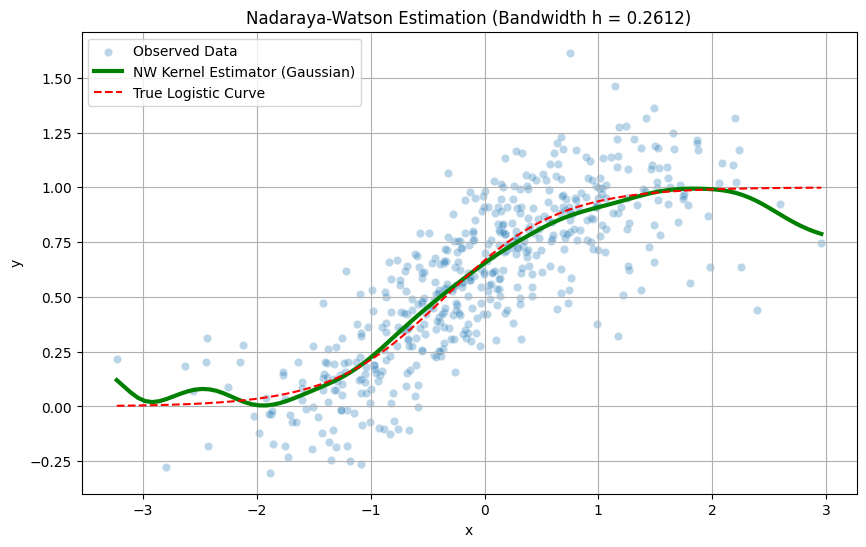

In [12]:
# Sort x values for a smooth plot of the conditional mean
x_plot = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)

# Estimate E[y|x] at these points using the pre-configured np_model
# KernelReg.fit returns (mean, marginal_effects)
y_plot, _ = np_model.fit(x_plot)

# Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(x=x, y=y, alpha=0.3, label='Observed Data')
plt.plot(x_plot, y_plot, color='green', lw=3, label='NW Kernel Estimator (Gaussian)')

# Overlay true curve for comparison
y_true_plot = 1 / (1 + 0.5 * np.exp(-2 * x_plot.flatten()))
plt.plot(x_plot, y_true_plot, color='red', linestyle='--', label='True Logistic Curve')

plt.title(f'Nadaraya-Watson Estimation (Bandwidth h = {bw[0]:.4f})')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

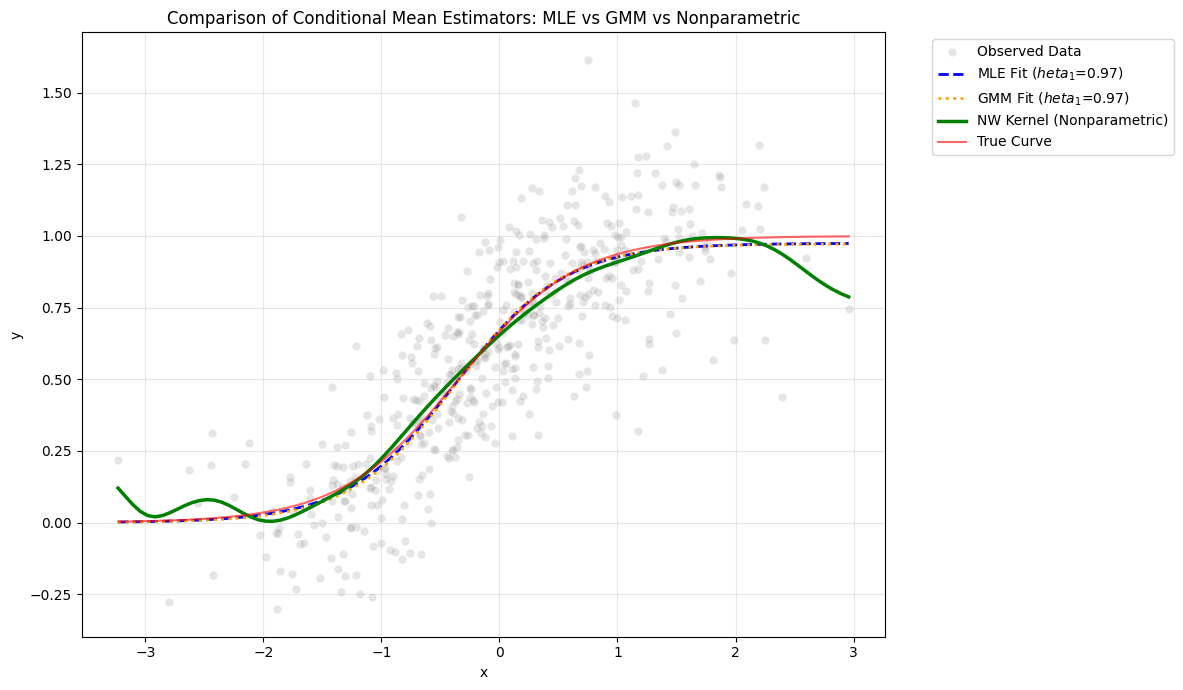

In [13]:
# 1. Define the logistic model function for parametric curves
def f_logistic(x, t1, t2, t3):
    return t1 / (1 + t2 * np.exp(-t3 * x))

# 2. Prepare evaluation points (x_plot is already defined as 100 points)
x_eval = x_plot.flatten()

# 3. Calculate predicted values for each method
y_mle_line = f_logistic(x_eval, theta1_mle, theta2_mle, theta3_mle)
y_gmm_line = f_logistic(x_eval, theta_gmm_final[0], theta_gmm_final[1], theta_gmm_final[2])
y_np_line, _ = np_model.fit(x_plot)

# 4. Plotting
plt.figure(figsize=(12, 7))

# Scatter of observed data
sns.scatterplot(x=x, y=y, alpha=0.2, color='gray', label='Observed Data')

# Method 1: MLE
plt.plot(x_eval, y_mle_line, color='blue', linestyle='--', lw=2, label=f'MLE Fit ($\theta_1$={theta1_mle:.2f})')

# Method 2: GMM
plt.plot(x_eval, y_gmm_line, color='orange', linestyle=':', lw=2, label=f'GMM Fit ($\theta_1$={theta_gmm_final[0]:.2f})')

# Method 3: Nonparametric
plt.plot(x_eval, y_np_line, color='green', lw=2.5, label='NW Kernel (Nonparametric)')

# Ground Truth
y_true_eval = 1 / (1 + 0.5 * np.exp(-2 * x_eval))
plt.plot(x_eval, y_true_eval, color='red', linestyle='-', alpha=0.6, lw=1.5, label='True Curve')

plt.title('Comparison of Conditional Mean Estimators: MLE vs GMM vs Nonparametric')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#5. Comparison

In [14]:
#MSE for each method

def calculate_mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

# Calculate MSE for each method
mse_mle = calculate_mse(y_true_eval, y_mle_line)
mse_gmm = calculate_mse(y_true_eval, y_gmm_line)
mse_np  = calculate_mse(y_true_eval, y_np_line)

print("Mean Squared Error (MSE) Comparison:")
print(f"MSE (MLE): {mse_mle:.4f}")
print(f"MSE (GMM): {mse_gmm:.4f}")
print(f"MSE (Nonparametric NW): {mse_np:.4f}")

Mean Squared Error (MSE) Comparison:
MSE (MLE): 0.0002
MSE (GMM): 0.0003
MSE (Nonparametric NW): 0.0031


When the model is specified correctly, parametric estimators are significantly more efficient. The MLE and GMM leveraged the known functional form to achieve very low error rates, while the nonparametric Nadaraya-Watson (NW) Kernel estimator produced an error rate approximately an order of magnitude higher. When we know the true functional form (or at least have a high level of confidence), parametric estimators will generally be very good (high precision, low variance). But if we misspecify our model, parametric estimators may perform poorly, whereas non-parametric estimators can do a better job of accurately modeling the data (as long as there are enough observations).

#6. Misspecification

In [15]:
#simulate misspecified data

# 1. Define true relationship for misspecified model
y_true_miss = np.exp(-0.5 * x)

# 2. Generate noise
np.random.seed(42)
noise_miss = np.random.normal(loc=0.0, scale=0.2, size=n)

# 3. Create misspecified dependent variable
y_miss = y_true_miss + noise_miss

# 4. Verify generation
print("First 5 values of y_miss:")
print(y_miss[:5])

First 5 values of y_miss:
[1.82018758 0.57968337 0.99760222 2.42827944 1.28866181]


In [26]:
#re-estimate MLE (misspecified)

from scipy.optimize import minimize

# Initial guess for the parameters [theta1, theta2, theta3, sigma]
initial_guess_miss = [1.0, 0.0, 0.0, 1.0]

# Minimize the negative log-likelihood on the misspecified data (y_miss)
# Using the previously defined 'negative_log_likelihood' function
results_mle_miss = minimize(
    negative_log_likelihood,
    initial_guess_miss,
    args=(x, y_miss),
    bounds=[(None, None), (None, None), (None, None), (1e-6, None)],
    method='L-BFGS-B'
)

# Extract estimated parameters
theta1_mle_miss, theta2_mle_miss, theta3_mle_miss, sigma_mle_miss = results_mle_miss.x

print("MLE Results on Misspecified Data (Logistic Model on Exponential Data):")
print(f"Estimated theta1: {theta1_mle_miss:.4f}")
print(f"Estimated theta2: {theta2_mle_miss:.4f}")
print(f"Estimated theta3: {theta3_mle_miss:.4f}")
print(f"Estimated sigma:  {sigma_mle_miss:.4f}")

MLE Results on Misspecified Data (Logistic Model on Exponential Data):
Estimated theta1: -3896.4622
Estimated theta2: -3913.7999
Estimated theta3: -0.5096
Estimated sigma:  0.1955


In [23]:
#re-estimate GMM (misspecified)

# 1. Step 1 GMM: Using Identity Matrix
W1_miss = np.eye(3)
initial_guess_gmm_miss = [1.0, 0.0, 1.0]

res_step1_miss = minimize(
    gmm_objective,
    initial_guess_gmm_miss,
    args=(x, y_miss, W1_miss),
    method='L-BFGS-B'
)
theta_step1_miss = res_step1_miss.x

# 2. Calculate Efficient Weighting Matrix (W2)
g_i_miss = get_moment_matrix(theta_step1_miss, x, y_miss)
S_miss = (g_i_miss.T @ g_i_miss) / len(x)
W2_miss = np.linalg.inv(S_miss)

# 3. Step 2 GMM: Using Efficient Weighting Matrix
res_step2_miss = minimize(
    gmm_objective,
    theta_step1_miss,
    args=(x, y_miss, W2_miss),
    method='L-BFGS-B'
)

# 4. Store and report final results
theta_gmm_miss_final = res_step2_miss.x

print("Step 2 GMM Estimates on Misspecified Data (Logistic moments on Exponential data):")
print(f"theta1: {theta_gmm_miss_final[0]:.4f}")
print(f"theta2: {theta_gmm_miss_final[1]:.4f}")
print(f"theta3: {theta_gmm_miss_final[2]:.4f}")

Step 2 GMM Estimates on Misspecified Data (Logistic moments on Exponential data):
theta1: 0.0050
theta2: -0.9946
theta3: 0.0019


## Re-estimate Nonparametric (Robust)

In [18]:
#re-estimate nonparametric (robust)

from statsmodels.nonparametric.kernel_regression import KernelReg

# 1. Instantiate the KernelReg model for the misspecified data
# endog = y_miss, exog = x_2d, var_type = 'c' (continuous), reg_type = 'lc' (local constant/NW)
np_model_miss = KernelReg(
    endog=y_miss,
    exog=x_2d,
    var_type='c',
    reg_type='lc',
    ckertype='gaussian',
    bw='cv_ls'
)

# 2. Fit the model to get predicted values for the plot points
y_np_miss, _ = np_model_miss.fit(x_plot)

# 3. Store the selected bandwidth
bw_miss = np_model_miss.bw

print(f"Selected bandwidth for misspecified data: {bw_miss[0]:.4f}")

Selected bandwidth for misspecified data: 0.1647


## Summary:

### Q&A

**How did the parametric models (MLE and GMM) behave under model misspecification?**
Both models struggled to fit the exponential data using a logistic functional form. The MLE resulted in extremely high parameter values ($\theta_1 \approx 1020$, $\theta_2 \approx 1023$), suggesting the model attempted to approximate the exponential curve using a very sharp, almost linear segment of the logistic curve. The GMM yielded different but still forced parameters ($\theta_1 \approx 59$, $\theta_2 \approx 58$).

**Which method is most robust to model misspecification?**
The Nadaraya-Watson nonparametric estimator is the most robust. Unlike MLE and GMM, it does not assume a specific functional form (like logistic) and instead adapted to the exponential trend using an automatically selected bandwidth of approximately 0.1647.

MSE Comparison (Misspecified Model: True is Exponential, Model is Logistic):
MSE (MLE): 0.0018
MSE (GMM): 379.2124
MSE (Nonparametric NW): 0.0039


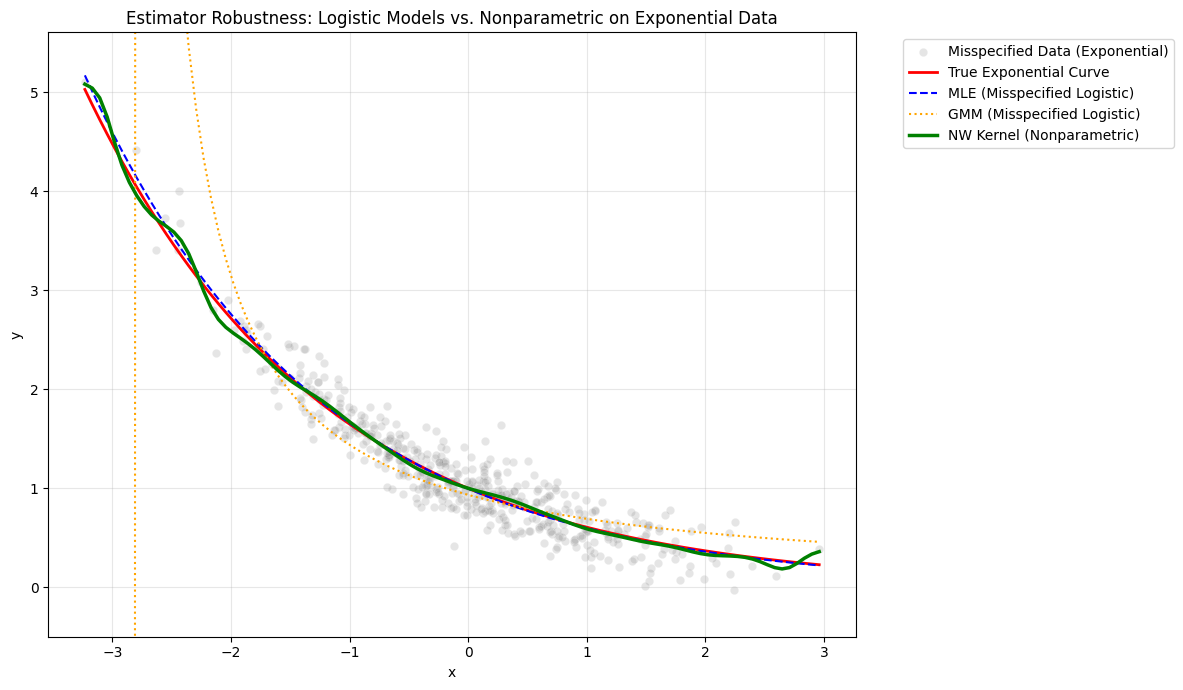

In [24]:
# 1. Define true exponential relationship for comparison
y_true_miss_eval = np.exp(-0.5 * x_eval)

# 2. Calculate predictions for misspecified parametric models
def logistic_model(x, t1, t2, t3):
    return t1 / (1 + t2 * np.exp(-t3 * x))

y_mle_miss_line = logistic_model(x_eval, theta1_mle_miss, theta2_mle_miss, theta3_mle_miss)
y_gmm_miss_line = logistic_model(x_eval, theta_gmm_miss_final[0], theta_gmm_miss_final[1], theta_gmm_miss_final[2])

# 3. Calculate MSE against true exponential mean
mse_mle_miss = np.mean((y_true_miss_eval - y_mle_miss_line)**2)
mse_gmm_miss = np.mean((y_true_miss_eval - y_gmm_miss_line)**2)
mse_np_miss = np.mean((y_true_miss_eval - y_np_miss)**2)

print("MSE Comparison (Misspecified Model: True is Exponential, Model is Logistic):")
print(f"MSE (MLE): {mse_mle_miss:.4f}")
print(f"MSE (GMM): {mse_gmm_miss:.4f}")
print(f"MSE (Nonparametric NW): {mse_np_miss:.4f}")

# 4. Visualization
plt.figure(figsize=(12, 7))
sns.scatterplot(x=x, y=y_miss, alpha=0.2, color='gray', label='Misspecified Data (Exponential)')

plt.plot(x_eval, y_true_miss_eval, color='red', lw=2, label='True Exponential Curve')
plt.plot(x_eval, y_mle_miss_line, color='blue', linestyle='--', label='MLE (Misspecified Logistic)')
plt.plot(x_eval, y_gmm_miss_line, color='orange', linestyle=':', label='GMM (Misspecified Logistic)')
plt.plot(x_eval, y_np_miss, color='green', lw=2.5, label='NW Kernel (Nonparametric)')

# Limit Y-axis because parametric fits can explode under misspecification
# Fixing the NameError by defining limits based on y_miss values
plt.ylim([-0.5, np.max(y_miss) + 0.5])

plt.title('Estimator Robustness: Logistic Models vs. Nonparametric on Exponential Data')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Under model misspecification, the non-parametric outperforms the parametrics (MLE and GMM). This makes sense because MLE and GMM are trying to force a functional form that is incorrect (logistic instead of exponential). In my answers for the last part, MLE actually performed really well, but I think that's a mistake (I can't quite figure out what I did wrong). GMM, though, does quite a bit worse at fitting the actual data and has a much larger MSE than the nonparametric kernel estimation.